In [24]:
import argparse
import json
import csv
import glob

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch

import random
import monai
from monai.data import CacheDataset, DataLoader
import monai.transforms as transforms

import nibabel as nib

#import seaborn as sns
import matplotlib.pyplot as plt

from multiprocessing import Pool
from functools import partial

from ipywidgets import Output, VBox
from IPython.display import display
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import IntSlider, interact

### **Unsupervised anomaly map based multicontrast stroke lesion analysis**

This notebook gathers raw anomaly maps (no absolute value) from FLAIR and ADC images of large lesions from the SOOP dataset\
It combines the anomaly maps with an atlas for vascular territory information

In [25]:
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
ROOT_DIR = "/home/fehrdelt/bettik/"

In [26]:
adc_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/adc_registered/"
flair_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/flair_registered/"

In [27]:
adc_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps_no_abs/exp_2_2/large/"

flair_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps_no_abs/exp_3_2/large/"

atlases_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/registered_atlases/"

In [28]:
unregistered_atlas = nib.load(f"{ROOT_DIR}datasets/registered_atlas_128.nii.gz").get_fdata()
atlas_zones_indexes = np.unique(unregistered_atlas)
atlas_zones_indexes = [int(idx) for idx in atlas_zones_indexes if idx != 0]
print("Atlas zones indexes:", atlas_zones_indexes)

Atlas zones indexes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32]


In [29]:
ano_adc = nib.load(f"{adc_anomaly_maps_folder}sub-374.nii.gz").get_fdata()
ano_flair = nib.load(f"{flair_anomaly_maps_folder}sub-374.nii.gz").get_fdata()
atlas = nib.load(f"{atlases_folder}sub-374.nii.gz").get_fdata()

atlas = atlas.astype(int)

In [30]:
zones_values = {zone:{'adc': None, 'flair': None} for zone in atlas_zones_indexes}

for zone_idx in atlas_zones_indexes:
    zone_mask = (atlas == zone_idx)
    if np.sum(zone_mask) == 0:
        print(f"Zone {zone_idx} has no voxels in the atlas for this subject, skipping.")
        continue
    
    adc_values = ano_adc[zone_mask]
    flair_values = ano_flair[zone_mask]

    mean_adc_value = np.mean(adc_values)
    mean_flair_value = np.mean(flair_values)

    zones_values[zone_idx]['adc'] = mean_adc_value
    zones_values[zone_idx]['flair'] = mean_flair_value

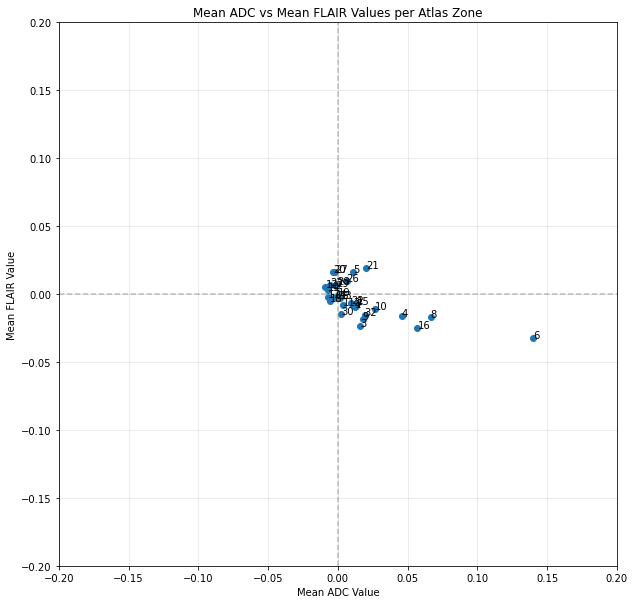

In [31]:
# Filter out zones with None values and plot
adc_vals = []
flair_vals = []
zone_labels = []

for zone_idx, values in zones_values.items():
    if values['adc'] is not None and values['flair'] is not None:
        adc_vals.append(values['adc'])
        flair_vals.append(values['flair'])
        zone_labels.append(zone_idx)


plt.figure(figsize=(10, 10))
plt.scatter(adc_vals, flair_vals)

# Add zone labels to each point
for i, zone in enumerate(zone_labels):
    plt.annotate(str(zone), (adc_vals[i], flair_vals[i]), fontsize=10)

plt.xlabel('Mean ADC Value')
plt.ylabel('Mean FLAIR Value')
plt.title('Mean ADC vs Mean FLAIR Values per Atlas Zone')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Center the plot on (0,0)
plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)

plt.show()

--------------------------------------------

In [32]:
# Get all patient files
adc_files = glob.glob(f"{adc_anomaly_maps_folder}*.nii.gz")
patient_ids = [os.path.basename(f).replace('.nii.gz', '') for f in adc_files]

# Create list to store all data
all_data = []

for patient_id in tqdm(patient_ids):
    ano_adc = nib.load(f"{adc_anomaly_maps_folder}{patient_id}.nii.gz").get_fdata()
    ano_flair = nib.load(f"{flair_anomaly_maps_folder}{patient_id}.nii.gz").get_fdata()
    atlas = nib.load(f"{atlases_folder}{patient_id}.nii.gz").get_fdata().astype(int)
    
    for zone_idx in atlas_zones_indexes:
        zone_mask = (atlas == zone_idx)
        if np.sum(zone_mask) == 0:
            continue
        
        mean_adc = -np.mean(ano_adc[zone_mask]) # negative value to make it more understandable (low ADC = lower values)
        mean_flair = -np.mean(ano_flair[zone_mask])
        
        all_data.append({
            'patient_id': patient_id,
            'zone': zone_idx,
            'mean_adc': mean_adc,
            'mean_flair': mean_flair
        })

df_zones = pd.DataFrame(all_data)
df_zones

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:29<00:00,  1.37it/s]


,patient_id,zone,mean_adc,mean_flair
0,sub-866,1,-0.022618,-0.016368
1,sub-866,2,-0.006966,-0.022396
2,sub-866,3,-0.036287,-0.040109
3,sub-866,4,-0.009441,-0.038192
4,sub-866,5,-0.102927,0.085945
...,...,...,...,...
1275,sub-525,27,0.012616,-0.044329
1276,sub-525,28,0.002184,-0.023327
1277,sub-525,29,0.006578,-0.022642
1278,sub-525,30,-0.063816,0.019518


-----------------

In [33]:
atlas_zones_names = {
    "anterior cerebral artery left": 1,
    "anterior cerebral artery right": 2,
    "medial lenticulostriate left": 3,
    "medial lenticulostriate right": 4,
    "lateral lenticulostriate left": 5,
    "lateral lenticulostriate right": 6,
    "frontal pars of middle cerebral artery left": 7,
    "frontal pars of middle cerebral artery right": 8,
    "parietal pars of middle cerebral artery left": 9,
    "parietal pars of middle cerebral artery right": 10,
    "temporal pars of middle cerebral artery left": 11,
    "temporal pars of middle cerebral artery right": 12,
    "occipital pars of middle cerebral artery left": 13,
    "occipital pars of middle cerebral artery right": 14,
    "insular pars of middle cerebral artery left": 15,
    "insular pars of middle cerebral artery right": 16,
    "temporal pars of posterior cerebral artery left": 17,
    "temporal pars of posterior cerebral artery right": 18,
    "occipital pars of posterior cerebral artery left": 19,
    "occipital pars of posterior cerebral artery right": 20,
    "posterior choroidal and thalamoperfurators left": 21,
    "posterior choroidal and thalamoperfurators right": 22,
    "anteior choroidal and thalamoperfurators left": 23,
    "anterior choroidal and thalamoperfurators right": 24,
    "basilar left": 25,
    "basilar right": 26,
    "superior cerebellar left": 27,
    "superior cerebellar right": 28,
    "inferior cerebellar left": 29,
    "inferior cerebellar right": 30,
    "lateral ventricle left": 31,
    "lateral ventricle right": 32	
}

**enlever les petites zones de l'atlas psk ça fait des erreurs**

In [34]:



fig = px.scatter(df_zones, x='mean_adc', y='mean_flair', 
                 color='patient_id', hover_data=['zone', 'patient_id'],
                 title='Mean ADC vs Mean FLAIR Values per Atlas Zone (All Patients)')

fig.update_layout(
    xaxis_title='Mean ADC Value',
    yaxis_title='Mean FLAIR Value',
    width=800, height=800
)

# Add reference lines
max_abs = max(df_zones['mean_adc'].abs().max(), df_zones['mean_flair'].abs().max())
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)

# Center the plot
fig.update_xaxes(range=[-max_abs * 1.1, max_abs * 1.1])
fig.update_yaxes(range=[-max_abs * 1.1, max_abs * 1.1])

# Add annotations for corners
fig.add_annotation(x=-max_abs, y=max_abs, text="Hypo ADC<br>Hyper FLAIR", showarrow=False, xanchor='left', yanchor='top')
fig.add_annotation(x=max_abs, y=max_abs, text="Hyper ADC<br>Hyper FLAIR", showarrow=False, xanchor='right', yanchor='top')
fig.add_annotation(x=-max_abs, y=-max_abs, text="Hypo ADC<br>Hypo FLAIR", showarrow=False, xanchor='left', yanchor='bottom')
fig.add_annotation(x=max_abs, y=-max_abs, text="Hyper ADC<br>Hypo FLAIR", showarrow=False, xanchor='right', yanchor='bottom')

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(legend_title_text='Patient ID', clickmode='event+select')


out = Output()

def on_click(trace, points, state):
    if points.point_inds:
        idx = points.point_inds[0]
        patient_id = df_zones.iloc[idx]['patient_id']
        zone = df_zones.iloc[idx]['zone']
        
        with out:
            out.clear_output(wait=True)
            
            ano_adc_img = nib.load(f"{adc_anomaly_maps_folder}{patient_id}.nii.gz").get_fdata()
            ano_flair_img = nib.load(f"{flair_anomaly_maps_folder}{patient_id}.nii.gz").get_fdata()
            adc_img = nib.load(f"{adc_folder}{patient_id}.nii.gz").get_fdata()
            flair_img = nib.load(f"{flair_folder}{patient_id}.nii.gz").get_fdata()
            atlas_img = nib.load(f"{atlases_folder}{patient_id}.nii.gz").get_fdata().astype(int)
            
            num_slices = ano_adc_img.shape[2]
            
            def update_slice(slice_idx):
                fig_img, axes = plt.subplots(2, 2, figsize=(12, 10))
                
                # Create zone contour for this slice
                zone_mask_slice = (atlas_img[:, :, slice_idx] == zone).astype(int)
                
                axes[0, 0].imshow(adc_img[:, :, slice_idx].T, origin='lower', cmap='gray')
                axes[0, 0].contour(zone_mask_slice.T, colors='red', linewidths=1)
                axes[0, 0].set_title(f'ADC - {patient_id} (slice {slice_idx})')
                axes[0, 0].axis('off')
                
                axes[0, 1].imshow(flair_img[:, :, slice_idx].T, origin='lower', cmap='gray')
                axes[0, 1].contour(zone_mask_slice.T, colors='red', linewidths=1)
                axes[0, 1].set_title(f'FLAIR - {patient_id} (slice {slice_idx})')
                axes[0, 1].axis('off')
                
                axes[1, 0].imshow(-ano_adc_img[:, :, slice_idx].T, origin='lower', cmap='bwr', vmin=-0.15, vmax=0.15) # here opposite sign just because we want hypo adc to be blue
                axes[1, 0].contour(zone_mask_slice.T, colors='black', linewidths=1)
                axes[1, 0].set_title(f'ADC Anomaly Map - {patient_id}')
                axes[1, 0].axis('off')
                
                axes[1, 1].imshow(-ano_flair_img[:, :, slice_idx].T, origin='lower', cmap='bwr', vmin=-0.15, vmax=0.15)
                axes[1, 1].contour(zone_mask_slice.T, colors='black', linewidths=1)
                axes[1, 1].set_title(f'FLAIR Anomaly Map - {patient_id}')
                axes[1, 1].axis('off')
                
                plt.suptitle(f'Patient: {patient_id}, Zone: {zone}')
                plt.tight_layout()
                plt.show()
            
            slice_slider = IntSlider(min=0, max=num_slices-1, step=1, value=num_slices//2, description='Slice:')
            interact(update_slice, slice_idx=slice_slider)

fig_widget = go.FigureWidget(fig)
with fig_widget.batch_update():
    for trace in fig_widget.data:
        trace.on_click(on_click)

display(VBox([fig_widget, out]))

    'data': [{'customdata': array([[1, 'sub-866'],
                             …

In [35]:



fig = px.scatter(df_zones, x='mean_adc', y='mean_flair', 
                 color='patient_id', hover_data=['zone', 'patient_id'],
                 title='Mean ADC vs Mean FLAIR Values per Atlas Zone (All Patients)')

fig.update_layout(
    xaxis_title='Mean ADC Value',
    yaxis_title='Mean FLAIR Value',
    width=800, height=800
)

# Add reference lines
max_abs = max(df_zones['mean_adc'].abs().max(), df_zones['mean_flair'].abs().max())
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)

# Center the plot
fig.update_xaxes(range=[-max_abs * 1.1, max_abs * 1.1])
fig.update_yaxes(range=[-max_abs * 1.1, max_abs * 1.1])

# Add annotations for corners
fig.add_annotation(x=-max_abs, y=max_abs, text="Hypo ADC<br>Hyper FLAIR", showarrow=False, xanchor='left', yanchor='top')
fig.add_annotation(x=max_abs, y=max_abs, text="Hyper ADC<br>Hyper FLAIR", showarrow=False, xanchor='right', yanchor='top')
fig.add_annotation(x=-max_abs, y=-max_abs, text="Hypo ADC<br>Hypo FLAIR", showarrow=False, xanchor='left', yanchor='bottom')
fig.add_annotation(x=max_abs, y=-max_abs, text="Hyper ADC<br>Hypo FLAIR", showarrow=False, xanchor='right', yanchor='bottom')

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(legend_title_text='Patient ID', clickmode='event+select')


out = Output()

def on_click(trace, points, state):
    
    if points.point_inds:
        
        with out:
            out.clear_output(wait=True)
            idx = points.point_inds[0]
            
            patient_name = points.trace_name
            
            zone = df_zones.iloc[idx]['zone']
            
            # Get zone name from atlas_zones_names
            zone_name = [name for name, idx in atlas_zones_names.items() if idx == zone]
            zone_name = zone_name[0] if zone_name else f"Unknown zone {zone}"
        
        
            
            print(patient_id)
            print(f"Zone: {zone} - {zone_name}")
            
            ano_adc_img = nib.load(f"{adc_anomaly_maps_folder}{patient_name}.nii.gz").get_fdata()
            ano_flair_img = nib.load(f"{flair_anomaly_maps_folder}{patient_name}.nii.gz").get_fdata()
            adc_img = nib.load(f"{adc_folder}{patient_name}.nii.gz").get_fdata()
            flair_img = nib.load(f"{flair_folder}{patient_name}.nii.gz").get_fdata()
            atlas_img = nib.load(f"{atlases_folder}{patient_name}.nii.gz").get_fdata().astype(int)
            
            num_slices = ano_adc_img.shape[2]
            
            def update_slice(slice_idx):
                fig_img, axes = plt.subplots(2, 2, figsize=(12, 10))
                
                # Create zone contour for this slice
                zone_mask_slice = (atlas_img[:, :, slice_idx] == zone).astype(int)
                
                axes[0, 0].imshow(adc_img[:, :, slice_idx].T, origin='lower', cmap='gray')
                axes[0, 0].contour(zone_mask_slice.T, colors='red', linewidths=1)
                axes[0, 0].set_title(f'ADC - {patient_name} (slice {slice_idx})')
                axes[0, 0].axis('off')
                
                axes[0, 1].imshow(flair_img[:, :, slice_idx].T, origin='lower', cmap='gray')
                axes[0, 1].contour(zone_mask_slice.T, colors='red', linewidths=1)
                axes[0, 1].set_title(f'FLAIR - {patient_name} (slice {slice_idx})')
                axes[0, 1].axis('off')
                
                axes[1, 0].imshow(-ano_adc_img[:, :, slice_idx].T, origin='lower', cmap='bwr', vmin=-0.15, vmax=0.15)
                axes[1, 0].contour(zone_mask_slice.T, colors='black', linewidths=1)
                axes[1, 0].set_title(f'ADC Anomaly Map - {patient_name}')
                axes[1, 0].axis('off')
                
                axes[1, 1].imshow(-ano_flair_img[:, :, slice_idx].T, origin='lower', cmap='bwr', vmin=-0.15, vmax=0.15)
                axes[1, 1].contour(zone_mask_slice.T, colors='black', linewidths=1)
                axes[1, 1].set_title(f'FLAIR Anomaly Map - {patient_name}')
                axes[1, 1].axis('off')
                
                plt.suptitle(f'Patient: {patient_name}, Zone: {zone} - {zone_name}')
                plt.tight_layout()
                plt.show()
            
            slice_slider = IntSlider(min=0, max=num_slices-1, step=1, value=num_slices//2, description='Slice:')
            interact(update_slice, slice_idx=slice_slider)

fig_widget = go.FigureWidget(fig)
with fig_widget.batch_update():
    for trace in fig_widget.data:
        trace.on_click(on_click)

display(VBox([fig_widget, out]))

    'data': [{'customdata': array([[1, 'sub-866'],
                             …